In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [15]:
words = open("names.txt").read().splitlines()
print(len(words))
words[:12]

32033


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily']

In [16]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


In [17]:
# build dataset
block_size = 3  #context length, how many characters do we take to predict the next character

def build_dataset(items):
  x_temp = []
  y_temp = []
  for w in items:
    context = [0] * block_size  #???
    for ch in w + '.':
      ix = stoi[ch]
      x_temp.append(context)
      y_temp.append(ix)
      # print(''.join(itos[i] for i in context), "--->", itos[ix])
      context = context[1:] + [ix]  # crop and append
  return torch.tensor(x_temp, device=device), torch.tensor(y_temp, device=device)

import random
random.seed(42)
random.shuffle(words)
n = len(words)
x_train, y_train = build_dataset(words[:int(0.8*n)])
x_dev, y_dev = build_dataset(words[int(0.8*n):int(0.9*n)])
x_test, y_test = build_dataset(words[int(0.9*n):])

x_train.shape, y_train.shape, x_dev.shape, y_dev.shape, x_test.shape, y_test.shape


(torch.Size([182625, 3]),
 torch.Size([182625]),
 torch.Size([22655, 3]),
 torch.Size([22655]),
 torch.Size([22866, 3]),
 torch.Size([22866]))

In [18]:
g = torch.Generator(device=device).manual_seed(2147483647)
#F.one_hot(torch.tensor(5), num_classes=27).float() @ C
emb_size = 10  # embedding dimension
C = torch.randn((27, emb_size), requires_grad=True, generator=g, device=device)
W1 = torch.randn((emb_size * block_size, 200), requires_grad=True, generator=g, device=device)
b1 = torch.randn(200, requires_grad=True, generator=g, device=device)
W2 = torch.randn((200, 27), requires_grad=True, generator=g, device=device)
b2 = torch.randn(27, requires_grad=True, generator=g, device=device)
parameters = [C, W1, b1, W2, b2]
print('number of parameters:', sum(p.nelement() for p in parameters))
BATCH_SIZE = 32


number of parameters: 11897


In [19]:
lossi = []
stepi = []

Final Loss =  1.9781668186187744


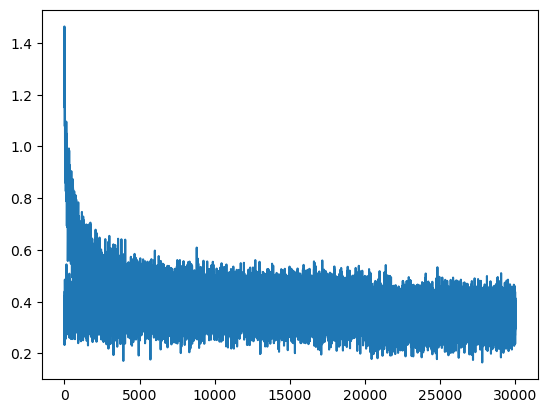

In [23]:
# training loop
for i in range(30000):
  # minibatch of 32
  ix = torch.randint(0, x_train.shape[0], (BATCH_SIZE,), generator=g, device=device)
  Xb, Yb = x_train[ix], y_train[ix]
  emb = C[Xb]
  z = emb.view(-1, emb_size * block_size)
  h = torch.tanh(z @ W1 + b1)
  logits = h @ W2 + b2
  # probs = F.softmax(logits, dim=1)
  # loss = -torch.log(probs[torch.arange(BATCH_SIZE), Yb]).mean()
  loss = F.cross_entropy(logits, Yb)   # Yb shape (B,)
  # print(i, loss.item())
  # set grad to 0, zero_grad()
  for p in [C, W1, b1, W2, b2]:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

# softmax activation
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# built-in softmax

print('Final Loss = ', loss.item())

# computes all gradients
for p in parameters:
  p.data -= 0.01 * p.grad

plt.plot(stepi, lossi)

In [27]:
emb = C[x_dev]
h = torch.tanh(emb.view(-1, emb_size * block_size) @ W1 + b1) # shape ()
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y_dev)
loss

tensor(2.2349, device='cuda:0', grad_fn=<NllLossBackward0>)

In [28]:
emb = C[x_test]
h = torch.tanh(emb.view(-1, emb_size * block_size) @ W1 + b1) # shape ()
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y_test)
loss

tensor(2.2309, device='cuda:0', grad_fn=<NllLossBackward0>)

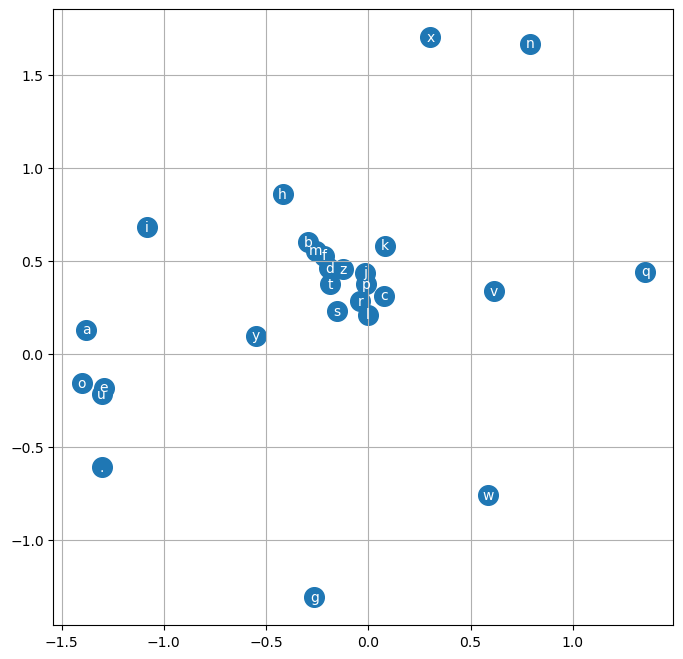

In [25]:
# visualize the chars
C_plot = C.detach().cpu()

plt.figure(figsize=(8, 8))
plt.scatter(C_plot[:, 0].numpy(), C_plot[:, 1].numpy(), s=200)
for i in range(C_plot.shape[0]):
    plt.text(C_plot[i, 0].item(), C_plot[i, 1].item(), itos[i],
             ha="center", va="center", color="white")
plt.grid(True, which="both")


In [26]:
# ---- inference: next-char prediction for a 4-char context ----
@torch.no_grad()
def predict_next_char(context4):
    # context4 must have length 4
    x = torch.tensor([[stoi[c] for c in context4]], dtype=torch.long)  # (1,4)
    emb = C[x]                       # (1,4,10)
    z = emb.view(1, emb_size * block_size)               # (1,40)
    h = torch.tanh(z @ W1 + b1)      # (1,200)
    logits = h @ W2 + b2             # (1,27)
    probs = F.softmax(logits, dim=1) # (1,27)
    ix = torch.argmax(probs, dim=1).item()
    return itos[ix], probs[0]

ch, probs = predict_next_char("onl")
print("predicted next char:", ch)

# ---- optional: generate a word ----
@torch.no_grad()
def generate_one():
    context = [0] * block_size
    out = []
    while True:
        x = torch.tensor([context], dtype=torch.long)   # (1,4)
        emb = C[x]
        z = emb.view(1, -1)
        h = torch.tanh(z @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        if ix == 0:   # '.' token
            break
        out.append(itos[ix])
    return "".join(out)

for _ in range(20):
  print(generate_one())

predicted next char: e
quic
ahri
somruina
ganc
edon
saish
say
keyzadazi
wan
arielachyranidlisis
zos
jaley
jon
kaine
emanaisiana
asia
maring
nicedaina
ham
ait
